# 10 — The client deliverable

This notebook turns the earlier analysis into a one-page valuation report for a lender, homeowner or acquisitions manager who will never open a notebook. The people who act on a valuation need a number, a range around it, the comparable sales behind it and a short list of reasons for caution, rather than accuracy metrics. Each report combines the valuation (03), its confidence range (04), the neighbourhood bias measured against it (04), the screening score (06) and the monitoring status (05), so errors in any of those would show up here. Checked against the 862 held-out sales, the quoted 80% range covers **78.8%** with quarterly recalibration (76.7% without, §5). To see the output, run the last cell and open one of the HTML files it writes to `reports/valuations/`.

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

from ames.avm import duan_smearing_factor, error_parity, split_calibration
from ames.compat import silence_spurious_matmul_warnings
from ames.config import ARMS_LENGTH_CONDITION, CONFORMAL_ALPHA, PROCESSED, REPORTS, SEED
from ames.data import load_properties
from ames.features import prepare
from ames.report import (build_flags, build_valuation_report, find_comparables,
                         save_report)
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
pd.set_option("display.width", 150)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "10 · Client deliverable"
SOURCE = "Source: De Cock (2011) · 862 held-out arm's-length sales."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

data = prepare(load_properties())
universe = data[(data["Sale Condition"] == ARMS_LENGTH_CONDITION)
                & (~data["is_outlier_grlivarea"])].copy()
artifacts = joblib.load(PROCESSED / "avm_model.joblib")
screening = pd.read_parquet(PROCESSED / "screening_scores.parquet").set_index("PID")
monitoring = json.loads((PROCESSED / "monitoring_summary.json").read_text())

print(f"{len(universe):,} properties available to report on")
print(f"monitoring status at last review: "
      f"{'BREACH' if monitoring['live_breach'] else 'all controls within limits'}")

2,412 properties available to report on
monitoring status at last review: all controls within limits


## 1. Assembling everything a single report needs

Five separate components, each from a different notebook, have to line up on one page.

In [2]:
train = universe[universe["temporal_split"] == "train"]
test = universe[universe["temporal_split"] == "test"]

# Valuation built the way notebook 04 validated.  Each range is the one the report would
# have carried when the valuation was issued: Mondrian bands recalibrated each quarter on
# the sales that had closed in the previous twelve months (notebook 05).  Checking the
# promise against these is honest; checking it against today's served bands would not
# be, because those were calibrated on the same 2009-2010 sales.
proper_idx, calib_idx = split_calibration(train.index, 0.5, SEED)
model = clone(artifacts["estimator"]).fit(universe.loc[proper_idx],
                                          np.log(universe.loc[proper_idx, "SalePrice"]))
smear = np.log(duan_smearing_factor(
    np.log(universe.loc[proper_idx, "SalePrice"]) - model.predict(universe.loc[proper_idx])))
issued = pd.read_parquet(PROCESSED / "recalibrated_intervals.parquet").set_index("PID")
MEASURED_COVERAGE = json.loads((PROCESSED / "recalibration.json").read_text())["backtest"]["coverage_rolling"]

test = test.copy()
test["avm_value"] = np.exp(model.predict(test) + smear)
# Same frozen model as notebook 05's calibration model, so the valuations must agree.
assert np.allclose(test["avm_value"], test["PID"].map(issued["predicted"]), rtol=1e-9)
q_issued = test["PID"].map(issued["q"])
test["value_low"] = test["avm_value"] * np.exp(-q_issued)
test["value_high"] = test["avm_value"] * np.exp(q_issued)
test["band"] = test["PID"].map(issued["band"])
test["quarter"] = test["PID"].map(issued["quarter"])
test["relative_width"] = (test["value_high"] - test["value_low"]) / test["avm_value"]

# Neighbourhood bias, measured on held-out sales (notebook 04).
parity = error_parity(test["SalePrice"], test["avm_value"], test["Neighborhood"], min_n=20)
bias_by_neighborhood = parity.set_index("group")["mean_signed_error"].to_dict()

# Screening score (notebook 06).
test["screening_score"] = test["PID"].map(screening["score"]).fillna(0.0)

ingredients = pd.Series({
    "properties reportable": len(test),
    "80% interval width, mean (share of value)": test["relative_width"].mean(),
    "80% interval width, cheapest band": test.loc[test["band"] == 1, "relative_width"].mean(),
    "neighbourhoods with a measured bias": len(bias_by_neighborhood),
    "worst measured neighbourhood bias": min(bias_by_neighborhood.values()),
    "properties with a screening score": int(test["screening_score"].gt(0).sum()),
}).to_frame("value")
ingredients.round(4)

,value
properties reportable,862.0000
"80% interval width, mean (share of value)",0.2240
"80% interval width, cheapest band",0.2998
neighbourhoods with a measured bias,14.0000
worst measured neighbourhood bias,-0.0398
properties with a screening score,862.0000


## 2. What goes on the page, and what does not

Most of the editorial work is deciding what to leave out. Every item below was available:

| Available | On the report? | Why |
|---|---|---|
| Point valuation | **Yes**, as the headline | It is what was asked for |
| 80% confidence range | **Yes**, beside it in dollars | Quoting a point invites treating it as exact |
| Comparable sales | **Yes**, with the selection rule stated | Lets the reader check the reasoning rather than trust it |
| Neighbourhood bias | **Yes**, as a plain-English caution | It is a known, measured weakness for *this* property |
| Screening score | **Yes**, but only when it is high | A 3% flag is noise; a 60% flag changes what you do |
| MdAPE, PPE10, FSD | **No** | Vocabulary the reader does not have; the range says the same thing |
| SHAP values | **No** | "Contribution to log-price" is not a sentence anyone acts on |
| Moran's I, conformal α | **No** | Method detail; it belongs in the methodology document |

A footer of two short paragraphs says how the model was built and where it is weak. That is the only methodology on the page.

## 3. Generating reports

Three properties exercise different paths through the logic: an ordinary home, an expensive one where notebook 04 found the model reads low, and one the screen flags.

In [3]:
def make_report(row: pd.Series, pool: pd.DataFrame, n_comparables: int = 5):
    """Assemble one client report from the pieces above."""
    comps = find_comparables(row, pool, n=n_comparables)
    flags = build_flags(
        row,
        value=row["avm_value"], lo=row["value_low"], hi=row["value_high"],
        neighborhood_bias=bias_by_neighborhood.get(row["Neighborhood"]),
        screening_score=row["screening_score"],
        n_comparables=len(comps),
    )
    html = build_valuation_report(row, row["avm_value"], row["value_low"],
                                  row["value_high"], comps, flags,
                                  measured_coverage=MEASURED_COVERAGE)
    return html, comps, flags

# The pool of possible comparables is *sold* properties -- a comparable has to be a
# recorded sale, not another modelled estimate.
pool = universe

typical = test.iloc[(test["avm_value"] - test["avm_value"].median()).abs().argsort()].iloc[0]
expensive = test.nlargest(1, "avm_value").iloc[0]
flagged = test.nlargest(1, "screening_score").iloc[0]

selection = {"typical": typical, "expensive": expensive, "flagged": flagged}
pd.DataFrame({
    name: {"Neighborhood": r["Neighborhood"], "sq ft": r["Gr Liv Area"],
           "built": r["Year Built"], "AVM value": r["avm_value"],
           "range": f"{money(r['value_low'])} – {money(r['value_high'])}",
           "actual sale price": r["SalePrice"],
           "screening score": r["screening_score"]}
    for name, r in selection.items()}).T

,Neighborhood,sq ft,built,AVM value,range,actual sale price,screening score
typical,OldTown,1690,1910,161920.037665,$146k – $179k,156500,0.059583
expensive,NridgHt,2696,2003,437332.523243,$389k – $491k,500000,0.059553
flagged,CollgCr,1222,2010,172667.080207,$155k – $192k,187000,0.924204


In [4]:
written = {}
for name, row in selection.items():
    html, comps, flags = make_report(row, pool)
    path = save_report(html, f"{name}_{int(row['PID'])}")
    written[name] = path
    print(f"{name:10s} -> {path.relative_to(REPORTS.parent)}  "
          f"({len(comps)} comparables, {len(flags)} notes: "
          f"{', '.join(f.level for f in flags)})")

typical    -> reports/valuations/typical_535382100.html  (5 comparables, 1 notes: good)
expensive  -> reports/valuations/expensive_528176010.html  (5 comparables, 2 notes: good, watch)
flagged    -> reports/valuations/flagged_906385020.html  (5 comparables, 2 notes: good, caution)


## 4. The cautions differ by property

The cautions are generated from measurements of each property's segment, so they change from one report to the next.

In [5]:
rows = []
for name, row in selection.items():
    _, comps, flags = make_report(row, pool)
    for f in flags:
        rows.append({"property": name, "level": f.level, "note": f.title})
pd.DataFrame(rows)

,property,level,note
0,typical,good,Valuation range is typical
1,expensive,good,Valuation range is typical
2,expensive,watch,Model tends to under-value this neighbourhood
3,flagged,good,Valuation range is typical
4,flagged,caution,Property resembles non-market transactions


### The `expensive` case

The model valued that home at **$437,333**, with a range of $389k–$491k. It sold for **$500,000**, outside the range, which by construction should happen to roughly one sale in five.

The report's neighbourhood note pointed the right way: *this model under-values homes in NridgHt by 3.5% on average*, measured on held-out sales in the same neighbourhood, a variable the reader knows. Adjusting by that amount gives about $452,000, still well short of the sale.

An earlier version also carried a price-band note (*across the top tenth of the price range it reads about 4% low, consider the upper end of the range*), and on this sale it happened to point toward the sale price. It has been withdrawn anyway. It quoted a figure measured by sale price against a trigger based on the valuation, and conditional on the valuation there is no such bias (notebook 04, decile-bias section). One sale cannot validate a note in either direction, and a measured weakness is only useful on the report if it is measured on a variable the reader has.

## 5. Does the range hold up?

The report tells the reader the sale price lands inside the quoted range 80% of the time. That claim can be checked against the 862 held-out sales, in dollars as the client sees it, not only in log space.

In [6]:
inside = ((test["SalePrice"] >= test["value_low"])
          & (test["SalePrice"] <= test["value_high"]))
print(f"promised: {1 - CONFORMAL_ALPHA:.0%} of sales inside the range")
print(f"observed: {inside.mean():.1%} of {len(test):,} held-out sales")
print(f"median range width: {money((test['value_high'] - test['value_low']).median())} "
      f"({test['relative_width'].median():.0%} of value)")

promised: 80% of sales inside the range
observed: 78.8% of 862 held-out sales
median range width: $33k (21% of value)


  saved reports/figures/10_report_promise.png


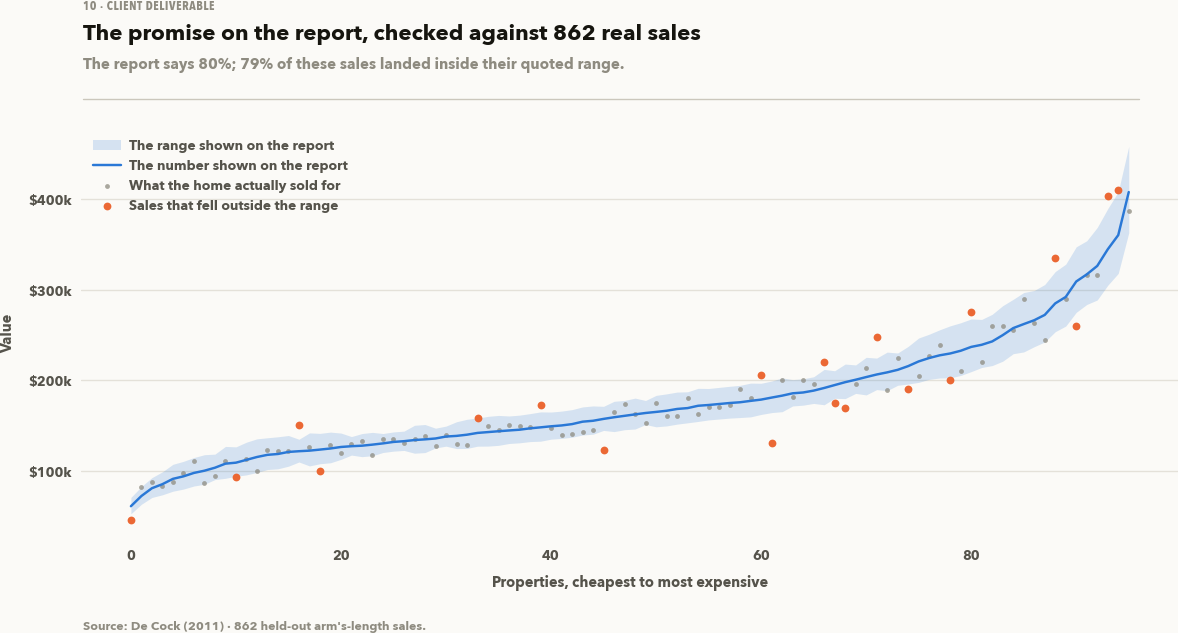

In [7]:
fig, ax = plt.subplots(figsize=(11.0, 6.3))
sample = test.sort_values("avm_value").iloc[::9].reset_index(drop=True)
x = np.arange(len(sample))
ax.fill_between(x, sample["value_low"], sample["value_high"], color=BLUE, alpha=0.18,
                lw=0, label="The range shown on the report")
ax.plot(x, sample["avm_value"], color=BLUE, lw=1.6, label="The number shown on the report")
covered = sample[(sample["SalePrice"] >= sample["value_low"])
                 & (sample["SalePrice"] <= sample["value_high"])]
missed = sample[~sample.index.isin(covered.index)]
ax.scatter(covered.index, covered["SalePrice"], s=10, color=INK_MUTED, alpha=0.75,
           linewidths=0, label="What the home actually sold for")
ax.scatter(missed.index, missed["SalePrice"], s=26, color=ORANGE, linewidths=0,
           label="Sales that fell outside the range")
ax.yaxis.set_major_formatter(money)
ax.set_xlabel("Properties, cheapest to most expensive")
ax.set_ylabel("Value")
ax.legend(loc="upper left", fontsize=9)
finish(fig, f"The promise on the report, checked against {len(test):,} real sales",
       f"The report says 80%; {inside.mean():.0%} of these sales landed inside their quoted range.")
save(fig, "10_report_promise")
plt.show()

**The observed coverage is 78.8%, against the 80% the report promises.** Each sale is checked against the range it would have been issued at the time: bands recalibrated each quarter on the sales closed in the previous twelve months (notebook 05). Calibrated once at launch instead, the same ranges covered 76.7%. Recalibration, the fix notebook 05 recommends, closes about two thirds of the gap.

The remaining gap is about one point. Conformal intervals guarantee coverage only when the calibration sales are *exchangeable* with the ones being valued, and a market that moves between calibration and valuation breaks that, even with a twelve-month window. Two ways to close the rest:

1. **A shorter or weighted window**, trading stability of the bands for recency.
2. **Widen the interval** until measured coverage reaches 80%, and quote that.

Until then, quoting 80% overstates the guarantee by about a point. The gap is small but real, and a client-facing document should not round it away.

The table below splits coverage by the valuation band each sale was issued in. The cheapest and top bands cover above 80%. The two furthest below target, bands 2 and 4 (roughly $122–145k and $172–216k), are the ones whose served width the latest recalibration has widened most. With about 170 sales per band, each band's coverage carries a standard error near three points, so this locates the gap without explaining it.

In [8]:
# How the issued ranges performed, by the valuation band each sale was issued in, and
# what width each band would have needed for the promise to hold exactly.
resid = np.abs(np.log(test["SalePrice"]) - np.log(test["avm_value"]))
needed = resid.groupby(test["band"]).quantile(1 - CONFORMAL_ALPHA)
honest = pd.DataFrame({
    "held-out sales": test["band"].value_counts().sort_index(),
    "coverage as issued": inside.groupby(test["band"]).mean(),
    "range issued (mean)": test.groupby("band")["relative_width"].mean(),
    "range needed": np.exp(needed) - np.exp(-needed),
})
honest.index.name = "band at issue"
print(honest.round(4).to_string())
needed_row = test["band"].map(needed)
print(f"\n-> the honest range averages {np.mean(np.exp(needed_row) - np.exp(-needed_row)):.0%} "
      f"of value; the issued ranges averaged {test['relative_width'].mean():.0%}")

               held-out sales  coverage as issued  range issued (mean)  range needed
band at issue                                                                       
1                         176              0.8182               0.2998        0.2881
2                         164              0.7378               0.2033        0.2178
3                         201              0.7960               0.1976        0.1915
4                         148              0.7635               0.1764        0.2042
5                         173              0.8150               0.2379        0.2268

-> the honest range averages 23% of value; the issued ranges averaged 22%


## 6. What a real deployment would add

Shipping the report to customers would need more:

| Gap | Why it matters |
|---|---|
| **A property address** | The report identifies homes by parcel number. Real users need an address, which the public data does not carry. |
| **Adverse action language** | If a valuation contributes to declining credit, US regulation requires specific disclosures. That is a compliance review, not a modelling task. |
| **A model version and run date** | Every report should be reproducible from the artefacts that produced it. |
| **Human override and audit trail** | Regulated valuation workflows need a reviewer to be able to disagree, with a recorded reason. |
| **Accessibility testing** | The layout works in light and dark mode and in print, but screen-reader behaviour has not been tested. |

### Summary

| Finding | Consequence |
|---|---|
| Five notebooks' output has to agree on one page | Inconsistencies between them surface in the deliverable |
| The hardest editorial decision is what to leave out | MdAPE, SHAP and Moran's I are all omitted; the range says what the reader needs |
| Cautions are generated from measurements, so they differ per property | Each report's warnings apply to that property's segment |
| The report's 80% promise measures 79% on held-out sales, with quarterly recalibration (77% without) | Closing the last point needs a shorter window, or a wider range with its validated coverage quoted |
| The `expensive` home sold outside its range, and the report's neighbourhood caution pointed the right way | Printing measured weaknesses beside the number tells the reader which way an error is likely to run |